In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [2]:
directmail=pd.read_csv('directmail.csv')
directmail

,RESPOND,AGE,BUY18,CLIMATE,FICO,INCOME,MARRIED,OWNHOME,GENDER
0,0,71.0,1,10,719.0,67.0,1.0,0.0,M
1,0,53.0,0,10,751.0,72.0,1.0,0.0,M
2,0,53.0,1,10,725.0,70.0,1.0,0.0,F
3,0,45.0,1,10,684.0,56.0,0.0,0.0,F
4,0,32.0,0,10,651.0,66.0,0.0,0.0,F
...,...,...,...,...,...,...,...,...,...
9995,0,41.0,0,30,672.0,18.0,1.0,1.0,F
9996,0,54.0,1,30,715.0,22.0,1.0,0.0,M
9997,0,47.0,0,30,703.0,50.0,0.0,0.0,F
9998,0,51.0,1,30,718.0,46.0,1.0,1.0,F


In [3]:
print(type(directmail))

<class 'pandas.core.frame.DataFrame'>


In [4]:
directmail.isnull().sum()

RESPOND      0
AGE        234
BUY18        0
CLIMATE      0
FICO        39
INCOME     234
MARRIED    234
OWNHOME    234
GENDER     234
dtype: int64

In [5]:
#여러 칼럼의 결측치값이 동일한 사용자에게 있어 해당 행을 제거함(임의로 채울 경우 왜곡 가능성이 높아보임)
directmail=directmail.dropna(subset=['AGE'])
directmail

,RESPOND,AGE,BUY18,CLIMATE,FICO,INCOME,MARRIED,OWNHOME,GENDER
0,0,71.0,1,10,719.0,67.0,1.0,0.0,M
1,0,53.0,0,10,751.0,72.0,1.0,0.0,M
2,0,53.0,1,10,725.0,70.0,1.0,0.0,F
3,0,45.0,1,10,684.0,56.0,0.0,0.0,F
4,0,32.0,0,10,651.0,66.0,0.0,0.0,F
...,...,...,...,...,...,...,...,...,...
9995,0,41.0,0,30,672.0,18.0,1.0,1.0,F
9996,0,54.0,1,30,715.0,22.0,1.0,0.0,M
9997,0,47.0,0,30,703.0,50.0,0.0,0.0,F
9998,0,51.0,1,30,718.0,46.0,1.0,1.0,F


In [6]:
directmail['FICO']=directmail['FICO'].fillna(directmail['FICO'].median())

In [7]:
X=directmail.drop('RESPOND',axis=1)
y=directmail['RESPOND']

In [8]:
#Q1
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.5, random_state=2039, stratify=y)

In [9]:
directmail.dtypes

RESPOND      int64
AGE        float64
BUY18        int64
CLIMATE      int64
FICO       float64
INCOME     float64
MARRIED    float64
OWNHOME    float64
GENDER      object
dtype: object

In [10]:
# 범주형 변수 더미변수화
X_train1 = pd.get_dummies(X_train1, columns=['GENDER'], drop_first=True, dtype=int)
X_test1 = pd.get_dummies(X_test1, columns=['GENDER'], drop_first=True, dtype=int)

In [11]:
#Q2
import statsmodels.api as sm

# 상수항 추기
X_train1_sm = sm.add_constant(X_train1) 

# 로지스틱 회귀 모델 적합 
m1_sm = sm.Logit(y_train1, X_train1_sm).fit()
print(m1_sm.summary())

Optimization terminated successfully.
         Current function value: 0.255365
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                RESPOND   No. Observations:                 4883
Model:                          Logit   Df Residuals:                     4874
Method:                           MLE   Df Model:                            8
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.03909
Time:                        04:33:44   Log-Likelihood:                -1246.9
converged:                       True   LL-Null:                       -1297.7
Covariance Type:            nonrobust   LLR p-value:                 2.150e-18
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6212      1.319      1.988      0.047       0.036       5.206
AGE           -0.0369      0.

In [12]:
X_train2 = X_train1.drop('INCOME', axis=1)
X_test2 = X_test1.drop('INCOME', axis=1)

In [13]:
X_train2_sm = sm.add_constant(X_train2) 
m2_sm = sm.Logit(y_train1, X_train2_sm).fit()
print(m2_sm.summary())

Optimization terminated successfully.
         Current function value: 0.255424
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                RESPOND   No. Observations:                 4883
Model:                          Logit   Df Residuals:                     4875
Method:                           MLE   Df Model:                            7
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.03887
Time:                        04:33:44   Log-Likelihood:                -1247.2
converged:                       True   LL-Null:                       -1297.7
Covariance Type:            nonrobust   LLR p-value:                 7.100e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4953      1.309      1.907      0.057      -0.070       5.060
AGE           -0.0368      0.

In [14]:
#최종모델 'GENDER','INCOME' 제거
X_train3 = X_train2.drop('GENDER_M', axis=1)
X_test3 = X_test2.drop('GENDER_M', axis=1)

In [15]:
X_train3_sm = sm.add_constant(X_train3) 
m3_sm = sm.Logit(y_train1, X_train3_sm).fit()
print(m3_sm.summary())

Optimization terminated successfully.
         Current function value: 0.255493
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                RESPOND   No. Observations:                 4883
Model:                          Logit   Df Residuals:                     4876
Method:                           MLE   Df Model:                            6
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                 0.03861
Time:                        04:33:45   Log-Likelihood:                -1247.6
converged:                       True   LL-Null:                       -1297.7
Covariance Type:            nonrobust   LLR p-value:                 2.274e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5683      1.306      1.966      0.049       0.008       5.128
AGE           -0.0367      0.

In [16]:
from sklearn.linear_model import LogisticRegression
m3= LogisticRegression(penalty=None, solver='newton-cholesky', random_state=0)
m3.fit(X_train3, y_train1)

LogisticRegression(penalty=None, random_state=0, solver='newton-cholesky')

In [17]:
m3_prob = m3.predict_proba(X_test3)
respond=pd.DataFrame(np.column_stack((m3_prob, y_test1)), 
        columns = ['P(Y=0)','P(Y=1)', 'Real Y']).sort_values(by='P(Y=1)',ascending=False)
respond.head()

,P(Y=0),P(Y=1),Real Y
875,0.640500,0.359500,0.0
1168,0.656546,0.343454,1.0
3387,0.664002,0.335998,0.0
3582,0.683046,0.316954,0.0
3806,0.690854,0.309146,0.0


In [18]:
from sklearn.linear_model import LogisticRegression
m1= LogisticRegression(penalty=None, solver='newton-cholesky', random_state=0)
m1.fit(X_train1, y_train1)

LogisticRegression(penalty=None, random_state=0, solver='newton-cholesky')

In [19]:
m1_prob = m1.predict_proba(X_test1)
respond1=pd.DataFrame(np.column_stack((m1_prob, y_test1)), 
        columns = ['P(Y=0)','P(Y=1)', 'Real Y']).sort_values(by='P(Y=1)',ascending=False)
respond1.head()

,P(Y=0),P(Y=1),Real Y
1168,0.628377,0.371623,1.0
3387,0.647866,0.352134,0.0
875,0.664049,0.335951,0.0
3806,0.666483,0.333517,0.0
2098,0.670054,0.329946,0.0


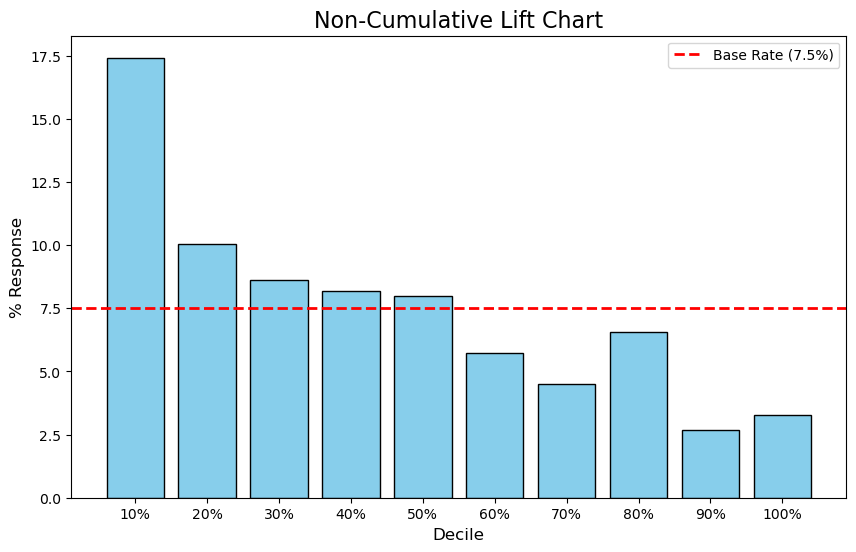

In [20]:
#Q3 FULL 모델
import matplotlib.pyplot as plt
total_len = len(respond1)
bin = total_len // 10 # 데이터를 10개의 구간으로 나눔

respond_list = []
for i in range(10):
    start = i * bin
    end = total_len if i == 9 else (i + 1) * bin 
    group = respond1.iloc[start:end]
    # % Response
    respond_rate = group['Real Y'].mean() * 100
    respond_list.append(respond_rate)

base_rate = respond1['Real Y'].mean() * 100 #전체 응답률
deciles = ['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']

plt.figure(figsize=(10, 6))
plt.bar(deciles, respond_list, color='skyblue', edgecolor='black')
plt.axhline(y=base_rate, color='red', linestyle='--', linewidth=2, label=f'Base Rate ({base_rate:.1f}%)')

plt.title('Non-Cumulative Lift Chart', fontsize=16)
plt.xlabel('Decile', fontsize=12)
plt.ylabel('% Response', fontsize=12)
plt.legend()
plt.show()

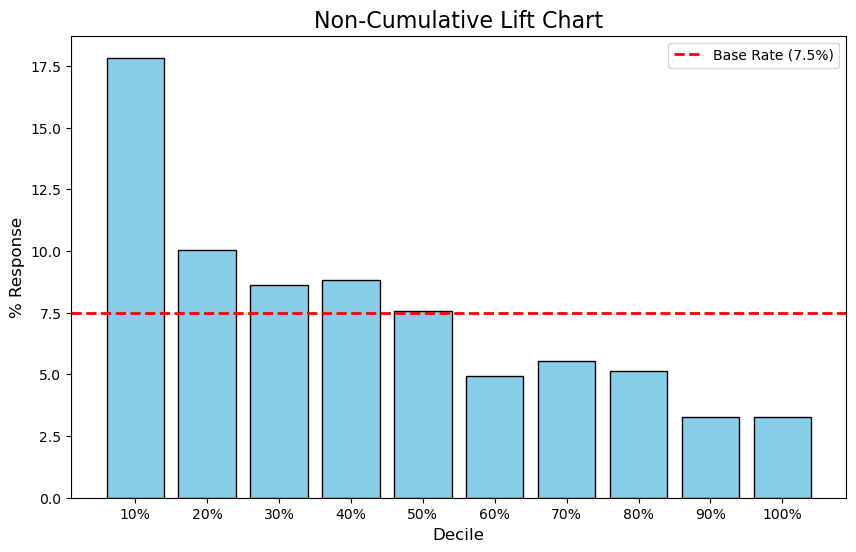

In [21]:
#Q3 최종 모델
import matplotlib.pyplot as plt
total_len = len(respond)
bin = total_len // 10 # 데이터를 10개의 구간으로 나눔

respond_list = []
for i in range(10):
    start = i * bin
    end = total_len if i == 9 else (i + 1) * bin 
    group = respond.iloc[start:end]
    # % Response
    respond_rate = group['Real Y'].mean() * 100
    respond_list.append(respond_rate)

base_rate = respond['Real Y'].mean() * 100 #전체 응답률
deciles = ['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']

plt.figure(figsize=(10, 6))
plt.bar(deciles, respond_list, color='skyblue', edgecolor='black')
plt.axhline(y=base_rate, color='red', linestyle='--', linewidth=2, label=f'Base Rate ({base_rate:.1f}%)')

plt.title('Non-Cumulative Lift Chart', fontsize=16)
plt.xlabel('Decile', fontsize=12)
plt.ylabel('% Response', fontsize=12)
plt.legend()
plt.show()

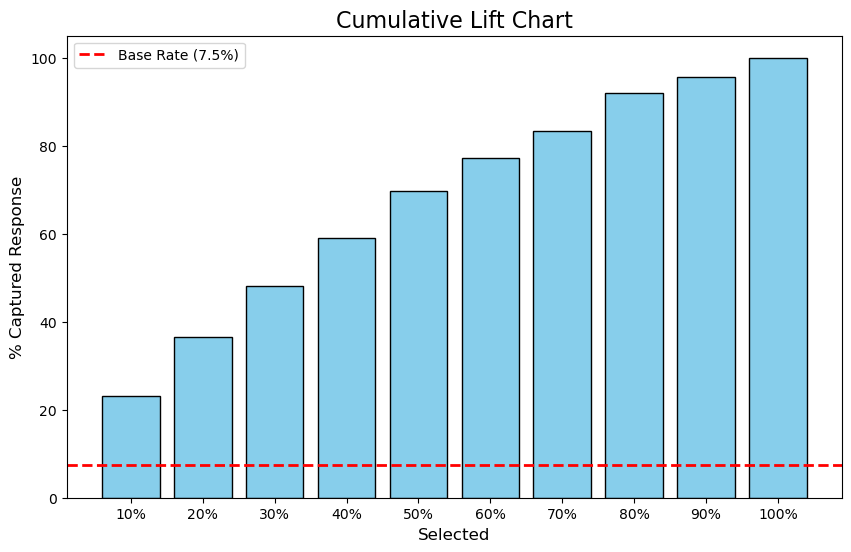

In [22]:
#Q4 FULL 모델
respond_list = [] 
total_respond = respond1['Real Y'].sum()

for i in range(10):
    start = 0
    end = total_len if i == 9 else (i + 1) * bin 
    group = respond1.iloc[start:end]
    
    # % Captured Response
    respond_rate = (group['Real Y'].sum()/total_respond)* 100
    respond_list.append(respond_rate)

# 전체 평균 응답률
base_rate = respond['Real Y'].mean() * 100
selected = ['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']

plt.figure(figsize=(10, 6))
plt.bar(selected, respond_list, color='skyblue', edgecolor='black')
plt.axhline(y=base_rate, color='red', linestyle='--', linewidth=2, label=f'Base Rate ({base_rate:.1f}%)')
plt.title('Cumulative Lift Chart', fontsize=16)
plt.xlabel('Selected', fontsize=12)
plt.ylabel('% Captured Response', fontsize=12)
plt.legend()
plt.show()

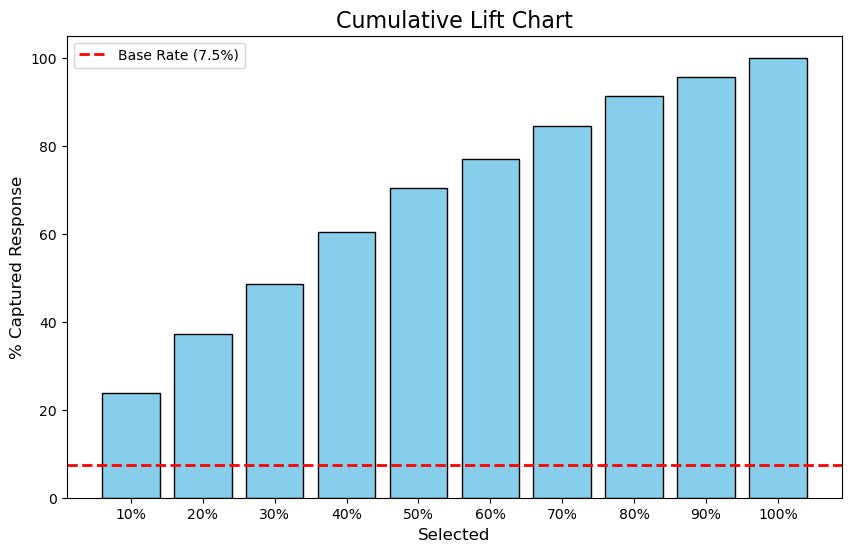

In [23]:
#Q4 최종모델
respond_list = [] 
total_respond = respond['Real Y'].sum()

for i in range(10):
    start = 0
    end = total_len if i == 9 else (i + 1) * bin 
    group = respond.iloc[start:end]
    
    # % Captured Response
    respond_rate = (group['Real Y'].sum()/total_respond)* 100
    respond_list.append(respond_rate)

# 전체 평균 응답률
base_rate = respond['Real Y'].mean() * 100
selected = ['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']

plt.figure(figsize=(10, 6))
plt.bar(selected, respond_list, color='skyblue', edgecolor='black')
plt.axhline(y=base_rate, color='red', linestyle='--', linewidth=2, label=f'Base Rate ({base_rate:.1f}%)')
plt.title('Cumulative Lift Chart', fontsize=16)
plt.xlabel('Selected', fontsize=12)
plt.ylabel('% Captured Response', fontsize=12)
plt.legend()
plt.show()

In [24]:
#Q5
#판결기준점을 0.3으로 하고 정확도를 구하기 위한 표 만듦
threshold = 0.1
m1_pred = (m1_prob[:, 1] > threshold).astype(int)
m1_cm = pd.crosstab(y_test1, m1_pred, rownames=['Actual (Real Y)'], colnames=['Predicted (m1)'])

print(m1_cm)

Predicted (m1)      0    1
Actual (Real Y)           
0                3667  850
1                 232  134


In [29]:
#FULL 모델
accu1 = np.trace(m1_cm)/len(y_test1)
print('정확도 :', np.round(accu1,4))

정확도 : 0.7784


In [26]:
# 최종 모델
m3_pred = (m3_prob[:, 1] > threshold).astype(int)
m3_cm = pd.crosstab(y_test1, m3_pred, rownames=['Actual (Real Y)'], colnames=['Predicted (m3)'])
print(m3_cm)

Predicted (m3)      0    1
Actual (Real Y)           
0                3668  849
1                 228  138


In [30]:
#최종 모델 ACCURACY
accu3 = np.trace(m3_cm)/len(y_test1)
print('정확도 :', np.round(accu3,4))

정확도 : 0.7794


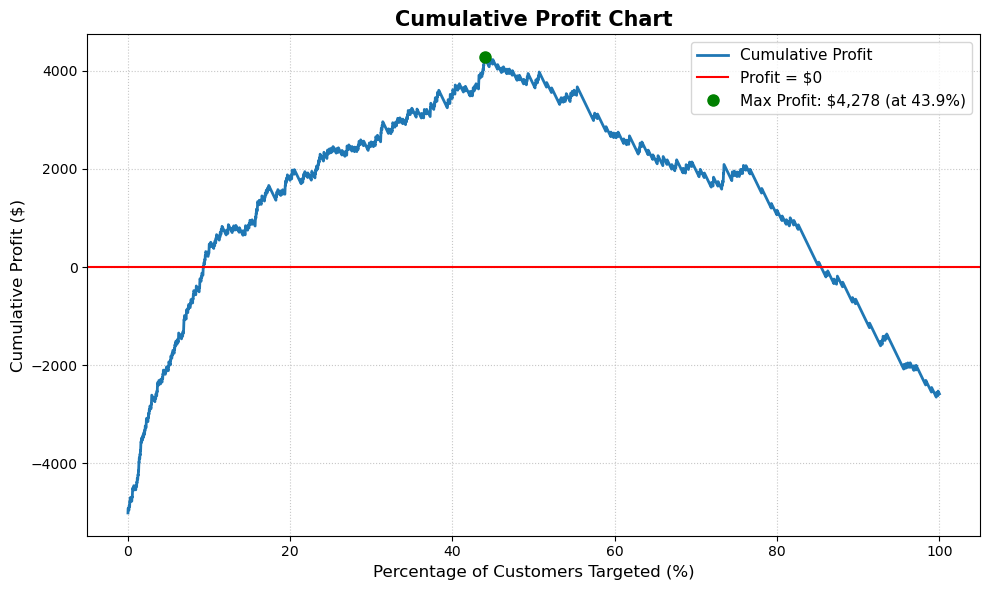

In [28]:
#7
fixed_cost = 5000        
cost_per_customer = 7    
avg_customer_value = 100 


# 누적 타겟팅 고객 수 (N)
respond['cumulative_target'] = np.arange(1, len(respond) + 1)
# 누적 실제 반응/전환 고객 수 (True Positives)
respond['cumulative_respond'] = respond['Real Y'].cumsum()

# 누적 비용, 누적 매출, 누적 수익 계산
respond['cost'] = fixed_cost + (respond['cumulative_target'] * cost_per_customer)
respond['revenue'] = respond['cumulative_respond'] * avg_customer_value
respond['profit'] = respond['revenue'] - respond['cost']

# X축으로 사용할 타겟팅 비율 계산
respond['target_percentage'] = (respond['cumulative_target'] / len(respond)) * 100

plt.figure(figsize=(10, 6))
# 수익 선 그래프
plt.plot(respond['target_percentage'], respond['profit'], label='Cumulative Profit', linewidth=2)
# 손익분기점 (Profit = 0) 선 긋기
plt.axhline(0, color='red', linestyle='-', label='Profit = $0')

# 최대 수익 지점 찾기 (최적의 타겟팅 비율)
max_profit_idx = respond['profit'].idxmax()
max_profit = respond.loc[max_profit_idx, 'profit']
best_target = respond.loc[max_profit_idx, 'target_percentage']

# 최대 수익 지점 표시
plt.plot(best_target, max_profit, 'go', markersize=8, 
         label=f'Max Profit: ${max_profit:,.0f} (at {best_target:.1f}%)')

# 그래프 
plt.title('Cumulative Profit Chart', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Customers Targeted (%)', fontsize=12)
plt.ylabel('Cumulative Profit ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# 그래프 출력
plt.show()